Why not Classification?

Answer:

Classification requires a target variable. This dataset has no target variable. We need to discover patterns automatically, therefore clustering is appropriate.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Why check missing values?

Answer:

Missing values may affect clustering and produce incorrect groups.

In [5]:
df.drop("CustomerID",
        axis=1,
        inplace=True)

does not help understand customer behavior.

In [6]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

Why encoding?

Answer:

KMeans uses distance calculations and cannot process text values.

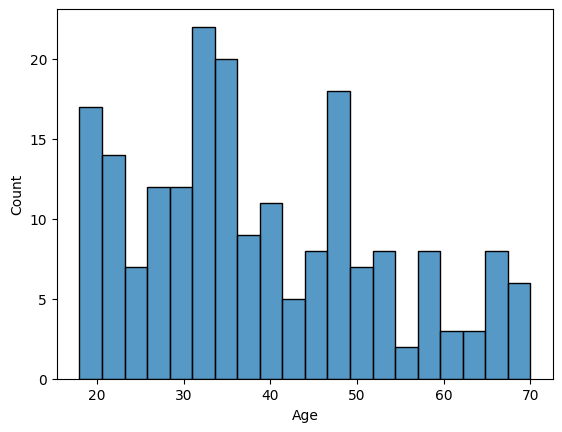

In [7]:
sns.histplot(df["Age"], bins=20)

plt.show()

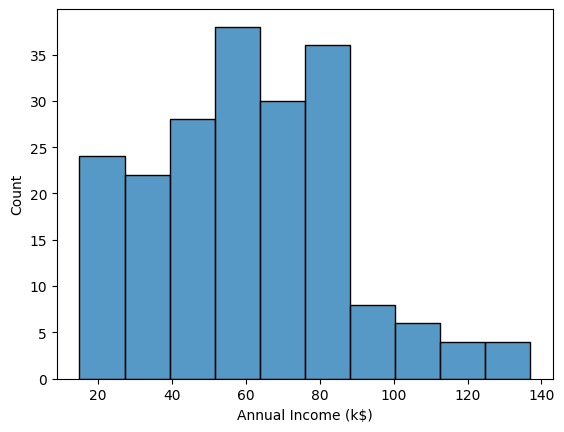

In [8]:
sns.histplot(df["Annual Income (k$)"])

plt.show()

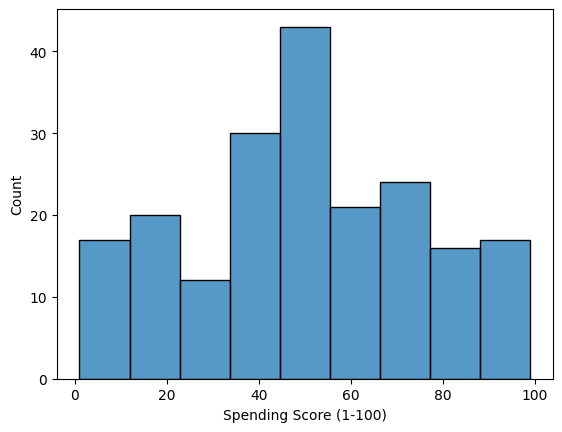

In [9]:
sns.histplot(df["Spending Score (1-100)"])

plt.show()

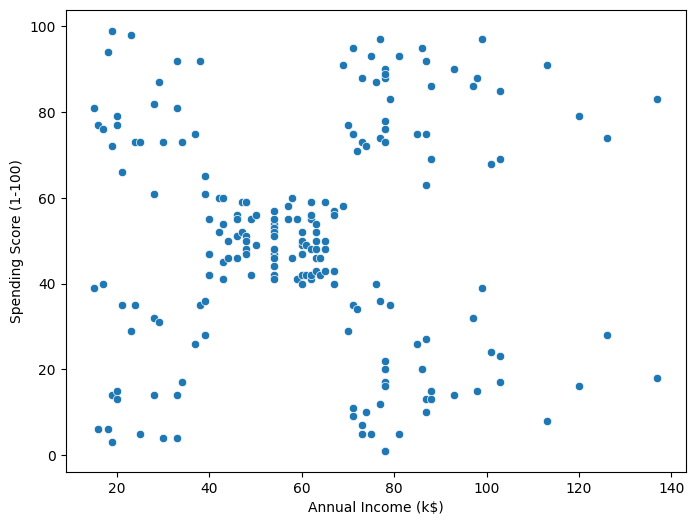

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"]
)

plt.show()

Why this graph?

Because customer segmentation is mainly based on:

Income
Spending

Why not use Age only?

Answer:

Spending behavior is more relevant for marketing decisions than age alone.

In [11]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

Why only these 2?

Because:

Income → Purchasing Capacity

Spending Score → Purchasing Behavior

Most business value.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

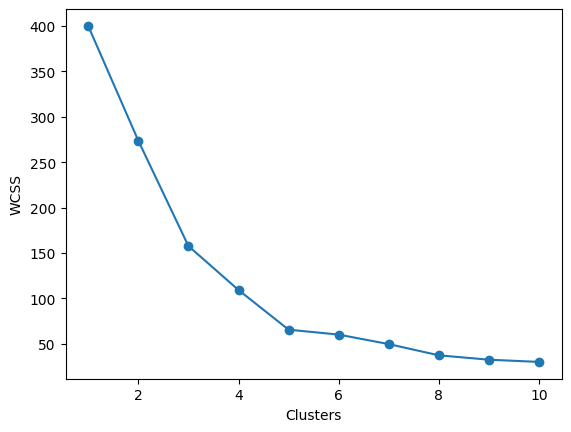

In [13]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

Why Elbow Method?

Answer:

It helps determine the optimal number of clusters.

In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

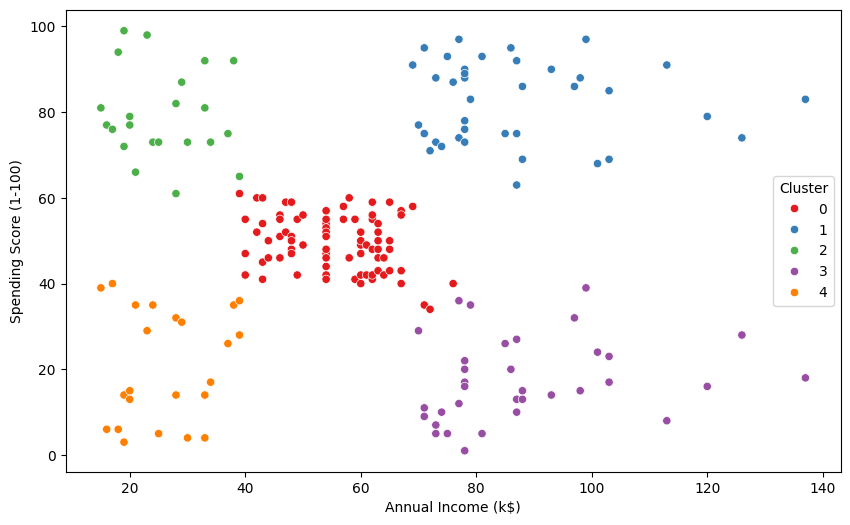

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette='Set1'
)

plt.show()

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print(score)

0.5546571631111091


Silhouette Score evaluates cluster quality by measuring how similar a point is to its own cluster compared to other clusters. Higher score indicates better separation.

Model Performance Report

Algorithm Used:
K-Means Clustering

Optimal Clusters:
5

Evaluation Metric:
Silhouette Score

Score Obtained:
0.555

Interpretation:
Clusters are well separated and meaningful for business decision making.

In [17]:
cluster_summary = df.groupby("Cluster")[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
